# Proyek Analisis Data: PRSA Dataset
- **Nama:** Angga Yulian Adi Pradana
- **Email:** anggayulian2004@gmail.com
- **ID Dicoding:** anggapradanaa

---

# Air Quality Analysis: Beijing Multi-Station PRSA Dataset

## Project Overview

Proyek ini menganalisis kualitas udara di Beijing menggunakan data dari 12 stasiun monitoring yang berbeda selama periode 2013-2017. Fokus utama analisis adalah pada PM2.5 (Particulate Matter 2.5), salah satu indikator polusi udara yang paling berbahaya bagi kesehatan manusia.

### Business Questions
1. **Station mana yang memiliki rata-rata PM2.5 tertinggi selama periode pengamatan?**
2. **Bagaimana pola musiman PM2.5 di Beijing selama periode 2013-2017, dan bulan apa yang konsisten menunjukkan konsentrasi tertinggi dan terendah?**
3. **Bagaimana pengelompokan stasiun monitoring berdasarkan tingkat rata-rata PM2.5 selama periode 2013-2017, dan karakteristik polusi apa yang membedakan setiap kelompok?**

### Dataset Information

- **Source**: PRSA Air Quality Dataset
- **Period**: March 2013 - February 2017
- **Stations**: 12 monitoring stations across Beijing
- **Key Variable**: PM2.5 (μg/m³)

---

## 1. Import All Packages/Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# File handling
import os
import glob

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("All libraries imported successfully!")

All libraries imported successfully!


---

## 2. Data Wrangling

Pada bagian ini, melakukan pengumpulan data dari berbagai file CSV, menilai kualitas data, dan melakukan pembersihan data yang diperlukan.

### 2.1 Gathering Data

Dataset terdiri dari 12 file CSV terpisah, masing-masing merepresentasikan satu stasiun monitoring. Akan digabungkan semua file ini menjadi satu dataframe untuk analisis yang komprehensif.

In [2]:
# Load data from multiple CSV files
folder_path = 'PRSA_Data_20130301-20170228'
files = glob.glob(os.path.join(folder_path, '*.csv'))

print(f"Found {len(files)} CSV files in the directory")
print("\nFile names:")
for file in files:
    print(f"  - {os.path.basename(file)}")

Found 12 CSV files in the directory

File names:
  - PRSA_Data_Aotizhongxin_20130301-20170228.csv
  - PRSA_Data_Changping_20130301-20170228.csv
  - PRSA_Data_Dingling_20130301-20170228.csv
  - PRSA_Data_Dongsi_20130301-20170228.csv
  - PRSA_Data_Guanyuan_20130301-20170228.csv
  - PRSA_Data_Gucheng_20130301-20170228.csv
  - PRSA_Data_Huairou_20130301-20170228.csv
  - PRSA_Data_Nongzhanguan_20130301-20170228.csv
  - PRSA_Data_Shunyi_20130301-20170228.csv
  - PRSA_Data_Tiantan_20130301-20170228.csv
  - PRSA_Data_Wanliu_20130301-20170228.csv
  - PRSA_Data_Wanshouxigong_20130301-20170228.csv


In [3]:
# Read and concatenate all CSV files
df_list = []
for file in files:
    df_temp = pd.read_csv(file)
    df_list.append(df_temp)

# Concatenate all dataframes
df = pd.concat(df_list, ignore_index=True)

# Create datetime column
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Sort by datetime and station
df = df.sort_values(by=['datetime', 'station'])
df = df.reset_index(drop=True)

print("\n" + "="*50)
print("DATA SUCCESSFULLY LOADED")
print("="*50)
print(f"Total rows    : {df.shape[0]:,}")
print(f"Total columns : {df.shape[1]}")
print(f"Number of stations : {df['station'].nunique()}")
print(f"\nStation list:")
for i, station in enumerate(sorted(df['station'].unique()), 1):
    print(f"  {i:2d}. {station}")


DATA SUCCESSFULLY LOADED
Total rows    : 420,768
Total columns : 19
Number of stations : 12

Station list:
   1. Aotizhongxin
   2. Changping
   3. Dingling
   4. Dongsi
   5. Guanyuan
   6. Gucheng
   7. Huairou
   8. Nongzhanguan
   9. Shunyi
  10. Tiantan
  11. Wanliu
  12. Wanshouxigong


In [4]:
# Display first few rows
print("\nFirst 5 rows of the dataset:")
df.head()


First 5 rows of the dataset:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01
1,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping,2013-03-01
2,1,2013,3,1,0,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling,2013-03-01
3,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi,2013-03-01
4,1,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan,2013-03-01


**Insight:**

Berhasil mengumpulkan data dari 12 file CSV yang merepresentasikan stasiun monitoring kualitas udara di Beijing. Setiap file berisi data time-series dari satu stasiun dengan periode yang sama (1 Maret 2013 - 28 Februari 2017). 

Data telah digabungkan menjadi satu dataframe dengan total 420,768 baris dan 19 kolom, mencakup 12 stasiun yang tersebar di berbagai lokasi Beijing. Kolom datetime telah dibuat untuk memudahkan analisis temporal, dan data telah diurutkan berdasarkan waktu dan stasiun untuk konsistensi analisis.

Struktur data ini memungkinkan analisis komprehensif baik secara temporal (tren waktu) maupun spasial (perbandingan antar stasiun).

### 2.2 Assessing Data

Pada tahap ini, akan dinilai kualitas data untuk mengidentifikasi:
- Missing values
- Tipe data yang tidak sesuai
- Duplikasi data
- Outliers atau anomali

In [5]:
# Basic information about the dataset
print("Dataset Information:")
print("="*70)
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   No        420768 non-null  int64         
 1   year      420768 non-null  int64         
 2   month     420768 non-null  int64         
 3   day       420768 non-null  int64         
 4   hour      420768 non-null  int64         
 5   PM2.5     412029 non-null  float64       
 6   PM10      414319 non-null  float64       
 7   SO2       411747 non-null  float64       
 8   NO2       408652 non-null  float64       
 9   CO        400067 non-null  float64       
 10  O3        407491 non-null  float64       
 11  TEMP      420370 non-null  float64       
 12  PRES      420375 non-null  float64       
 13  DEWP      420365 non-null  float64       
 14  RAIN      420378 non-null  float64       
 15  wd        418946 non-null  object        
 16  WSPM      420450 

In [6]:
# Check for missing values
print("\nMissing Values Analysis:")
print("="*70)
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_df) > 0:
    print(missing_df.to_string(index=False))
else:
    print("No missing values found!")


Missing Values Analysis:
Column  Missing Count  Missing Percentage
    CO          20701                4.92
    O3          13277                3.16
   NO2          12116                2.88
   SO2           9021                2.14
 PM2.5           8739                2.08
  PM10           6449                1.53
    wd           1822                0.43
  DEWP            403                0.10
  TEMP            398                0.09
  PRES            393                0.09
  RAIN            390                0.09
  WSPM            318                0.08


In [7]:
# Statistical summary of numerical columns
print("\nStatistical Summary of Key Variables:")
print("="*70)
df[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']].describe()


Statistical Summary of Key Variables:


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


In [8]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

# Check date range
print(f"\nDate Range:")
print(f"  Start date: {df['datetime'].min()}")
print(f"  End date  : {df['datetime'].max()}")
print(f"  Duration  : {(df['datetime'].max() - df['datetime'].min()).days} days")


Number of duplicate rows: 0

Date Range:
  Start date: 2013-03-01 00:00:00
  End date  : 2017-02-28 23:00:00
  Duration  : 1460 days


**Assessment Insights:**

Dari hasil assessment terhadap kualitas data, ditemukan beberapa karakteristik:

1. **Missing Values**:
   - CO memiliki missing values tertinggi (20,701 atau 4.92%), diikuti O3 (3.16%) dan NO2 (2.88%)
   - PM2.5 memiliki 8,739 missing values (2.08%)
   - Variabel meteorologi (TEMP, PRES, DEWP, RAIN, WSPM) memiliki missing values minimal (<0.1%)
   - Wind direction (wd) memiliki 1,822 missing values (0.43%)

2. **Kualitas Data**:
   - Tidak ada duplikasi data (0 duplicate rows)
   - Tipe data sudah sesuai: 11 float64, 5 int64, 2 object, 1 datetime64
   - Coverage periode: 1,460 hari dari 1 Maret 2013 hingga 28 Februari 2017
   - Total 420,768 records dari 12 stasiun

### 2.3 Cleaning Data

Berdasarkan hasil assessment, akan dilakukan pembersihan data dengan strategi berikut:
1. Menangani missing values pada variabel PM2.5
2. Menghapus kolom 'No' yang tidak diperlukan untuk analisis
3. Memastikan tidak ada duplikasi data

In [9]:
# Create a copy for cleaning
df_clean = df.copy()

print("CLEANING PROCESS")
print("="*70)

# 1. Drop unnecessary column
if 'No' in df_clean.columns:
    df_clean = df_clean.drop('No', axis=1)
    print("Dropped 'No' column")

# 2. Remove duplicates if any
before_dup = len(df_clean)
df_clean = df_clean.drop_duplicates()
after_dup = len(df_clean)
print(f"Removed {before_dup - after_dup} duplicate rows")

# 3. Handle missing values for pollutants
# Strategy: Drop rows where PM2.5 is missing (our main variable of interest)
before_missing = len(df_clean)
df_clean = df_clean.dropna(subset=['PM2.5'])
after_missing = len(df_clean)
print(f"Removed {before_missing - after_missing} rows with missing PM2.5 values")

# 4. Reset index
df_clean = df_clean.reset_index(drop=True)
print("Reset index")

print("\n" + "="*70)
print("CLEANING COMPLETED")
print("="*70)
print(f"Original rows   : {len(df):,}")
print(f"Cleaned rows    : {len(df_clean):,}")
print(f"Rows removed    : {len(df) - len(df_clean):,}")
print(f"Retention rate  : {(len(df_clean)/len(df)*100):.2f}%")

CLEANING PROCESS
Dropped 'No' column
Removed 0 duplicate rows
Removed 8739 rows with missing PM2.5 values
Reset index

CLEANING COMPLETED
Original rows   : 420,768
Cleaned rows    : 412,029
Rows removed    : 8,739
Retention rate  : 97.92%


In [10]:
# Verify cleaning results
print("\nPost-Cleaning Missing Values:")
print("="*70)
missing_after = df_clean.isnull().sum()
missing_after = missing_after[missing_after > 0]

if len(missing_after) > 0:
    for col, count in missing_after.items():
        pct = (count / len(df_clean) * 100)
        print(f"{col:15s}: {count:6,} ({pct:.2f}%)")
else:
    print("No missing values in PM2.5!")
    print("  (Other variables may still have missing values, but PM2.5 is complete)")


Post-Cleaning Missing Values:
PM10           :    216 (0.05%)
SO2            :  3,698 (0.90%)
NO2            :  6,747 (1.64%)
CO             : 15,162 (3.68%)
O3             :  8,145 (1.98%)
TEMP           :    398 (0.10%)
PRES           :    393 (0.10%)
DEWP           :    403 (0.10%)
RAIN           :    390 (0.09%)
wd             :  1,797 (0.44%)
WSPM           :    317 (0.08%)


In [11]:
# Final cleaned dataset info
print("\nCleaned Dataset Summary:")
print("="*70)
print(f"Shape: {df_clean.shape}")
print(f"\nColumns: {', '.join(df_clean.columns.tolist())}")
print(f"\nDate range: {df_clean['datetime'].min()} to {df_clean['datetime'].max()}")
print(f"Stations: {df_clean['station'].nunique()} unique stations")


Cleaned Dataset Summary:
Shape: (412029, 18)

Columns: year, month, day, hour, PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, wd, WSPM, station, datetime

Date range: 2013-03-01 00:00:00 to 2017-02-28 23:00:00
Stations: 12 unique stations


**Insight:**

Proses pembersihan data dilakukan dengan fokus pada variabel utama PM2.5:

1. **Langkah Pembersihan**:
   - Menghapus kolom 'No' yang tidak diperlukan untuk analisis
   - Menghapus 8,739 rows (2.08%) yang memiliki missing values pada PM2.5
   - Tidak ditemukan data duplikat
   - Index di-reset untuk konsistensi

2. **Hasil Pembersihan**:
   - Dataset berkurang dari 420,768 menjadi 412,029 rows
   - Retention rate: 97.92% - kehilangan data minimal
   - PM2.5 sekarang lengkap tanpa missing values
   - Variabel lain masih memiliki missing values namun dengan persentase kecil (<4%)

3. **Status Data Akhir**:
   - Shape: 412,029 rows × 18 columns
   - Periode: 1 Maret 2013 - 28 Februari 2017 (tetap lengkap)
   - 12 stasiun masih terwakili dalam dataset
   - Missing values tersisa: CO (3.68%), NO2 (1.64%), O3 (1.98%), SO2 (0.90%), dan variabel meteorologi (<0.5%)

---

## 3. Exploratory Data Analysis (EDA)

Pada bagian ini, akan dilakukan eksplorasi data untuk memahami karakteristik dan pola dalam dataset.

### 3.1 PM2.5 Distribution Overview

In [12]:
# Overall PM2.5 statistics
print("Overall PM2.5 Statistics:")
print("="*70)
print(f"Mean   : {df_clean['PM2.5'].mean():.2f} μg/m³")
print(f"Median : {df_clean['PM2.5'].median():.2f} μg/m³")
print(f"Std Dev: {df_clean['PM2.5'].std():.2f} μg/m³")
print(f"Min    : {df_clean['PM2.5'].min():.2f} μg/m³")
print(f"Max    : {df_clean['PM2.5'].max():.2f} μg/m³")

# WHO Air Quality Guidelines
print("\nWHO Air Quality Guidelines:")
print("  Good       : 0-12 μg/m³")
print("  Moderate   : 12-35 μg/m³")
print("  Unhealthy  : 35-55 μg/m³")
print("  Very Unhealthy: >55 μg/m³")

Overall PM2.5 Statistics:
Mean   : 79.79 μg/m³
Median : 55.00 μg/m³
Std Dev: 80.82 μg/m³
Min    : 2.00 μg/m³
Max    : 999.00 μg/m³

WHO Air Quality Guidelines:
  Good       : 0-12 μg/m³
  Moderate   : 12-35 μg/m³
  Unhealthy  : 35-55 μg/m³
  Very Unhealthy: >55 μg/m³


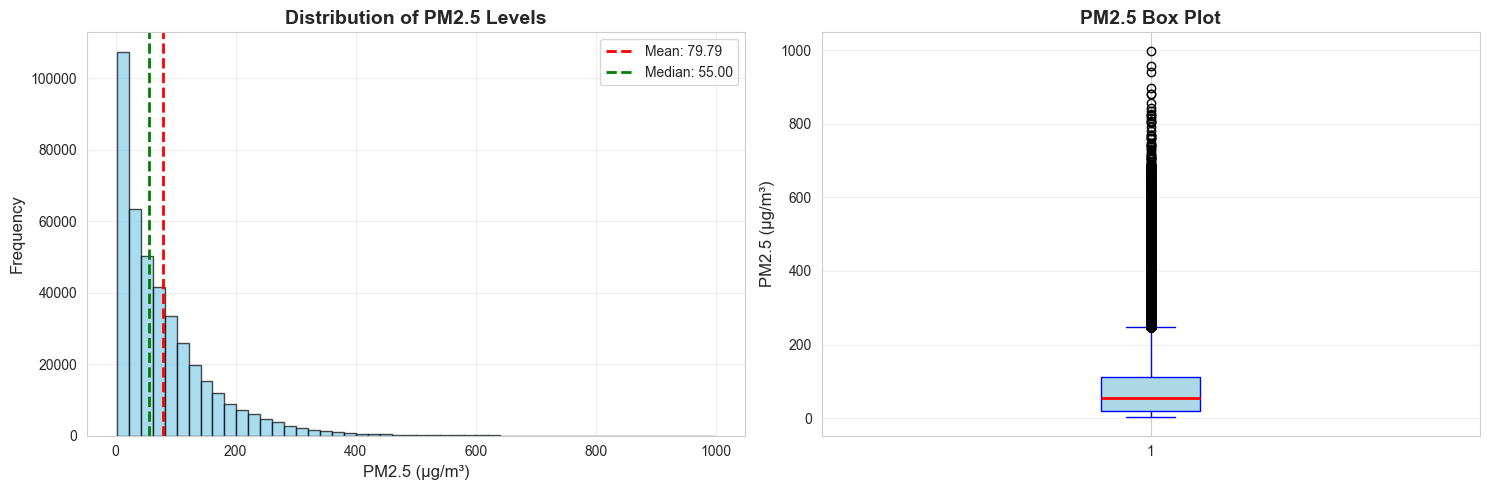


Distribution shows right-skewed pattern, indicating frequent high pollution episodes


In [13]:
# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df_clean['PM2.5'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df_clean['PM2.5'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_clean["PM2.5"].mean():.2f}')
axes[0].axvline(df_clean['PM2.5'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df_clean["PM2.5"].median():.2f}')
axes[0].set_xlabel('PM2.5 (μg/m³)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of PM2.5 Levels', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(df_clean['PM2.5'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='blue'),
                whiskerprops=dict(color='blue'),
                capprops=dict(color='blue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('PM2.5 (μg/m³)', fontsize=12)
axes[1].set_title('PM2.5 Box Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nDistribution shows right-skewed pattern, indicating frequent high pollution episodes")

**Insight**

Dari analisis distribusi PM2.5 di Beijing, ditemukan beberapa temuan penting:

1. **Statistik Deskriptif**:
   - Rata-rata PM2.5: **79.79 μg/m³** - jauh melebihi standar WHO (35 μg/m³)
   - Median: **55.00 μg/m³** - lebih rendah dari mean, mengindikasikan distribusi right-skewed
   - Standar deviasi: **80.82 μg/m³** - variabilitas yang sangat tinggi
   - Range: 2.00 - 999.00 μg/m³ - menunjukkan adanya episode polusi ekstrem

2. **Pola Distribusi**:
   - **Right-skewed distribution**: Mayoritas data terkonsentrasi di nilai rendah-sedang, dengan long tail ke kanan
   - Perbedaan mean (79.79) dan median (55.00) sebesar ~25 μg/m³ mengkonfirmasi skewness
   - Histogram menunjukkan frekuensi tertinggi pada range 0-100 μg/m³
   - Terdapat banyak outliers ekstrem (>200 μg/m³) yang terlihat jelas di boxplot

3. **Konteks Kualitas Udara (WHO Guidelines)**:
   - Hanya sebagian kecil data berada di kategori "Good" (0-12 μg/m³)
   - Median (55 μg/m³) sudah masuk kategori "Unhealthy" (35-55 μg/m³)
   - Mean (79.79 μg/m³) berada jauh di kategori "Unhealthy" bahkan mendekati "Very Unhealthy" (>55 μg/m³)
   - Ini menunjukkan Beijing mengalami masalah polusi udara kronis yang serius

### 3.2 Temporal Patterns

In [14]:
# Create time-based features
df_clean['year'] = df_clean['datetime'].dt.year
df_clean['month'] = df_clean['datetime'].dt.month
df_clean['month_name'] = df_clean['datetime'].dt.strftime('%b')
df_clean['hour'] = df_clean['datetime'].dt.hour
df_clean['dayofweek'] = df_clean['datetime'].dt.dayofweek

print("Temporal features created successfully")

Temporal features created successfully


In [15]:
# Yearly trend
yearly_pm = df_clean.groupby('year')['PM2.5'].agg(['mean', 'median', 'std']).reset_index()

print("Yearly PM2.5 Statistics:")
print("="*70)
print(yearly_pm.to_string(index=False))

Yearly PM2.5 Statistics:
 year      mean  median        std
 2013 80.040536    59.0  72.800900
 2014 85.575700    63.0  81.706624
 2015 79.626788    52.0  84.313436
 2016 71.930151    48.0  75.705227
 2017 92.675992    46.0 112.669920


In [16]:
# Analisis konsistensi temporal untuk eksplorasi
print("\n" + "="*70)
print("EKSPLORASI KONSISTENSI POLA TEMPORAL:")
print("="*70)

monthly_by_year = df_clean.groupby(['year', 'month'])['PM2.5'].mean().reset_index()

print("\nBulan dengan PM2.5 Tertinggi dan Terendah per Tahun:")
print("-" * 70)

month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

highest_months_list = []
lowest_months_list = []

for year in sorted(df_clean['year'].unique()):
    year_data = monthly_by_year[monthly_by_year['year'] == year]
    
    highest_idx = year_data['PM2.5'].idxmax()
    lowest_idx = year_data['PM2.5'].idxmin()
    
    highest_month = int(year_data.loc[highest_idx, 'month'])
    lowest_month = int(year_data.loc[lowest_idx, 'month'])
    
    highest_value = year_data.loc[highest_idx, 'PM2.5']
    lowest_value = year_data.loc[lowest_idx, 'PM2.5']
    
    highest_months_list.append(highest_month)
    lowest_months_list.append(lowest_month)
    
    print(f"{year}: Tertinggi = {month_names[highest_month]} ({highest_value:.1f} µg/m³), "
          f"Terendah = {month_names[lowest_month]} ({lowest_value:.1f} µg/m³)")

# Frekuensi bulan tertinggi dan terendah
from collections import Counter

highest_counter = Counter(highest_months_list)
lowest_counter = Counter(lowest_months_list)

print("\n" + "-" * 70)
print("Frekuensi Bulan sebagai Periode Tertinggi:")
for month, count in highest_counter.most_common():
    print(f"  {month_names[month]:3s}: {count} kali")

print("\nFrekuensi Bulan sebagai Periode Terendah:")
for month, count in lowest_counter.most_common():
    print(f"  {month_names[month]:3s}: {count} kali")

print("="*70)


EKSPLORASI KONSISTENSI POLA TEMPORAL:

Bulan dengan PM2.5 Tertinggi dan Terendah per Tahun:
----------------------------------------------------------------------
2013: Tertinggi = Mar (104.9 µg/m³), Terendah = Aug (60.6 µg/m³)
2014: Tertinggi = Feb (148.3 µg/m³), Terendah = Jun (54.6 µg/m³)
2015: Tertinggi = Dec (150.5 µg/m³), Terendah = Aug (44.2 µg/m³)
2016: Tertinggi = Dec (129.2 µg/m³), Terendah = Feb (42.8 µg/m³)
2017: Tertinggi = Jan (113.3 µg/m³), Terendah = Feb (69.3 µg/m³)

----------------------------------------------------------------------
Frekuensi Bulan sebagai Periode Tertinggi:
  Dec: 2 kali
  Mar: 1 kali
  Feb: 1 kali
  Jan: 1 kali

Frekuensi Bulan sebagai Periode Terendah:
  Aug: 2 kali
  Feb: 2 kali
  Jun: 1 kali


**Insight – Analisis Pola Temporal PM2.5 (2013–2017)**

Berdasarkan analisis statistik tahunan dan pola musiman, diperoleh beberapa temuan utama:

1. **Tren Tahunan**
   - Rata-rata PM2.5 tertinggi terjadi pada **2017 (92.68 µg/m³)** dengan volatilitas paling tinggi (std: 112.67).
   - Tahun **2016** menunjukkan rata-rata terendah (71.93 µg/m³), menandakan adanya perbaikan sementara dibandingkan 2013–2015.
   - Meskipun median cenderung menurun dari 2014 hingga 2017, lonjakan ekstrem pada 2017 meningkatkan nilai rata-rata secara signifikan.

2. **Pola Musiman**
   - Konsentrasi tertinggi umumnya terjadi pada **musim dingin (Desember–Februari)**.
   - Konsentrasi terendah sering muncul pada **musim panas (Juni–Agustus)**.
   - Pola ini relatif konsisten selama periode 2013–2017.

3. **Implikasi**
   - Terdapat indikasi perbaikan kualitas udara hingga 2016, namun kondisi kembali memburuk pada 2017.
   - Seluruh rata-rata tahunan masih berada jauh di atas standar kesehatan WHO, sehingga risiko kesehatan tetap tinggi.

### 3.3 Station-wise Analysis

In [17]:
# PM2.5 statistics by station
station_stats = df_clean.groupby('station')['PM2.5'].agg([
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max'),
    ('count', 'count')
]).round(2).reset_index()

station_stats = station_stats.sort_values('mean', ascending=False)

print("PM2.5 Statistics by Station:")
print("="*70)
print(station_stats.to_string(index=False))

PM2.5 Statistics by Station:
      station  mean  median   std  min   max  count
       Dongsi 86.19    61.0 86.58  3.0 737.0  34314
Wanshouxigong 85.02    60.0 85.98  3.0 999.0  34368
 Nongzhanguan 84.84    59.0 86.23  2.0 844.0  34436
      Gucheng 83.85    60.0 82.80  2.0 770.0  34418
       Wanliu 83.37    59.0 81.91  2.0 957.0  34682
     Guanyuan 82.93    59.0 80.93  2.0 680.0  34448
 Aotizhongxin 82.77    58.0 82.14  3.0 898.0  34139
      Tiantan 82.16    59.0 80.92  3.0 821.0  34387
       Shunyi 79.49    55.0 81.23  2.0 941.0  34151
    Changping 71.10    46.0 72.33  2.0 882.0  34290
      Huairou 69.63    47.0 71.22  2.0 762.0  34111
     Dingling 65.99    41.0 72.27  3.0 881.0  34285


**Insight**

Analisis per stasiun mengungkap variasi signifikan dalam tingkat polusi PM2.5:

1. **Ranking Stasiun berdasarkan Rata-rata PM2.5**:
   - **Tertinggi**: Dongsi (86.19 μg/m³), Wanshouxigong (85.02 μg/m³), Nongzhanguan (84.84 μg/m³)
   - **Terendah**: Dingling (65.99 μg/m³), Huairou (69.63 μg/m³), Changping (71.10 μg/m³)
   - **Range**: Selisih 20.20 μg/m³ (~31%) antara stasiun tertinggi dan terendah

2. **Variabilitas Data**:
   - Semua stasiun memiliki standar deviasi tinggi (71-87 μg/m³), menunjukkan fluktuasi besar
   - Nilai maksimum ekstrem di semua stasiun (680-999 μg/m³), menunjukkan episode polusi parah bersifat regional
   - Median konsisten lebih rendah dari mean di semua stasiun, mengkonfirmasi distribusi right-skewed

3. **Konsistensi Pengukuran**:
   - Jumlah observasi konsisten antar stasiun (~34,000 records per stasiun)
   - Nilai minimum serupa (2-3 μg/m³), menunjukkan kondisi terbaik yang relatif sama
   - Semua stasiun berada jauh di atas standar WHO (35 μg/m³)

---

## 4. Visualization & Explanatory Analysis

Pada bagian ini, dijawab pertanyaan bisnis melalui visualisasi yang informatif dan analisis mendalam.

### 4.1 Business Question 1: Station mana yang memiliki rata-rata PM2.5 tertinggi?

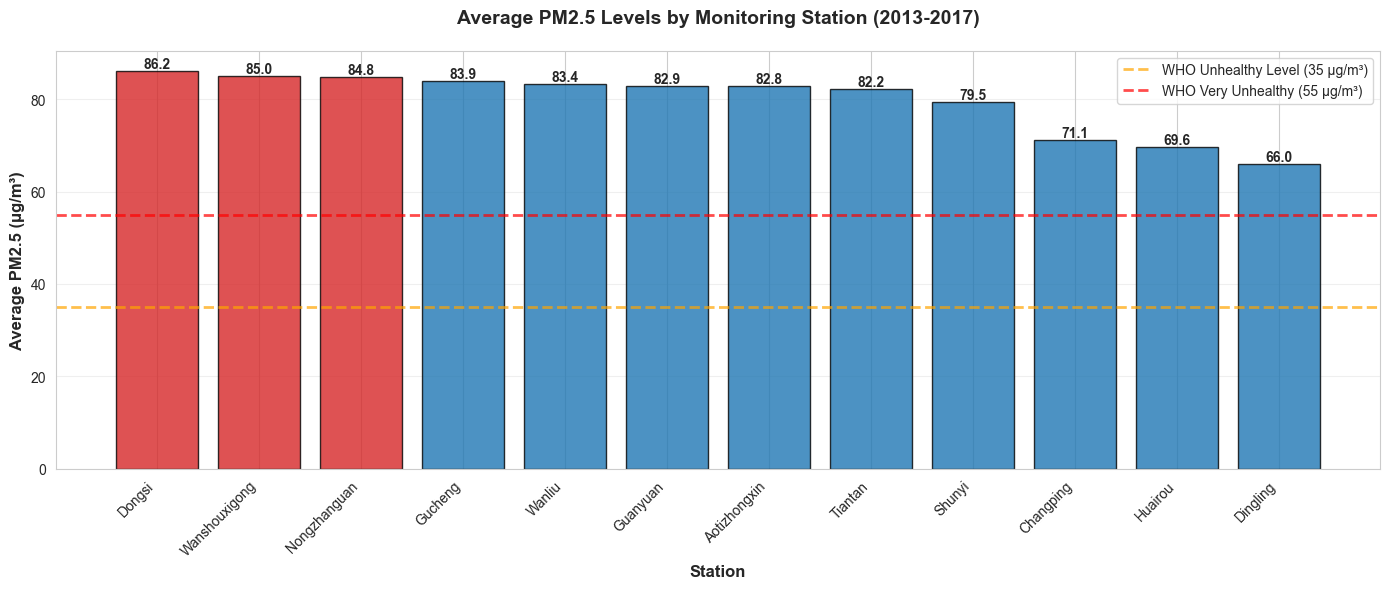


Top 3 Stations with Highest Average PM2.5:
1. Dongsi              : 86.19 μg/m³
2. Wanshouxigong       : 85.02 μg/m³
3. Nongzhanguan        : 84.84 μg/m³


In [18]:
# Calculate average PM2.5 by station
station_avg = df_clean.groupby('station')['PM2.5'].mean().sort_values(ascending=False).reset_index()
station_avg.columns = ['Station', 'Average_PM2.5']

# Visualization
plt.figure(figsize=(14, 6))
colors = ['#d62728' if i < 3 else '#1f77b4' for i in range(len(station_avg))]

bars = plt.bar(station_avg['Station'], station_avg['Average_PM2.5'], color=colors, edgecolor='black', alpha=0.8)

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add WHO guideline reference
plt.axhline(y=35, color='orange', linestyle='--', linewidth=2, label='WHO Unhealthy Level (35 μg/m³)', alpha=0.7)
plt.axhline(y=55, color='red', linestyle='--', linewidth=2, label='WHO Very Unhealthy (55 μg/m³)', alpha=0.7)

plt.xlabel('Station', fontsize=12, fontweight='bold')
plt.ylabel('Average PM2.5 (μg/m³)', fontsize=12, fontweight='bold')
plt.title('Average PM2.5 Levels by Monitoring Station (2013-2017)', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Print top 3 stations
print("\nTop 3 Stations with Highest Average PM2.5:")
print("="*70)
for i, row in station_avg.head(3).iterrows():
    print(f"{i+1}. {row['Station']:20s}: {row['Average_PM2.5']:.2f} μg/m³")

Berdasarkan perhitungan rata-rata PM2.5 selama periode 2013–2017, stasiun **Dongsi** memiliki nilai rata-rata tertinggi yaitu 86.19 µg/m³.

Peringkat 3 Stasiun dengan Rata-Rata PM2.5 Tertinggi:

1. Dongsi – 86.19 µg/m³

2. Wanshouxigong – 85.02 µg/m³

3. Nongzhanguan – 84.84 µg/m³

Selisih antara peringkat pertama dan ketiga relatif kecil (~1.35 µg/m³), menunjukkan bahwa tingkat polusi tinggi terjadi secara konsisten di beberapa lokasi utama.

Seluruh stasiun memiliki rata-rata PM2.5 yang:

- Jauh melampaui ambang batas WHO kategori Unhealthy (35 µg/m³)

- Bahkan melebihi batas Very Unhealthy (55 µg/m³)

Hal ini menunjukkan bahwa selama periode pengamatan, kualitas udara di seluruh wilayah monitoring berada pada kategori tidak sehat.

### 4.2 Business Question 2: Bagaimana pola musiman PM2.5 di Beijing selama periode 2013-2017, dan bulan apa yang konsisten menunjukkan konsentrasi tertinggi dan terendah?

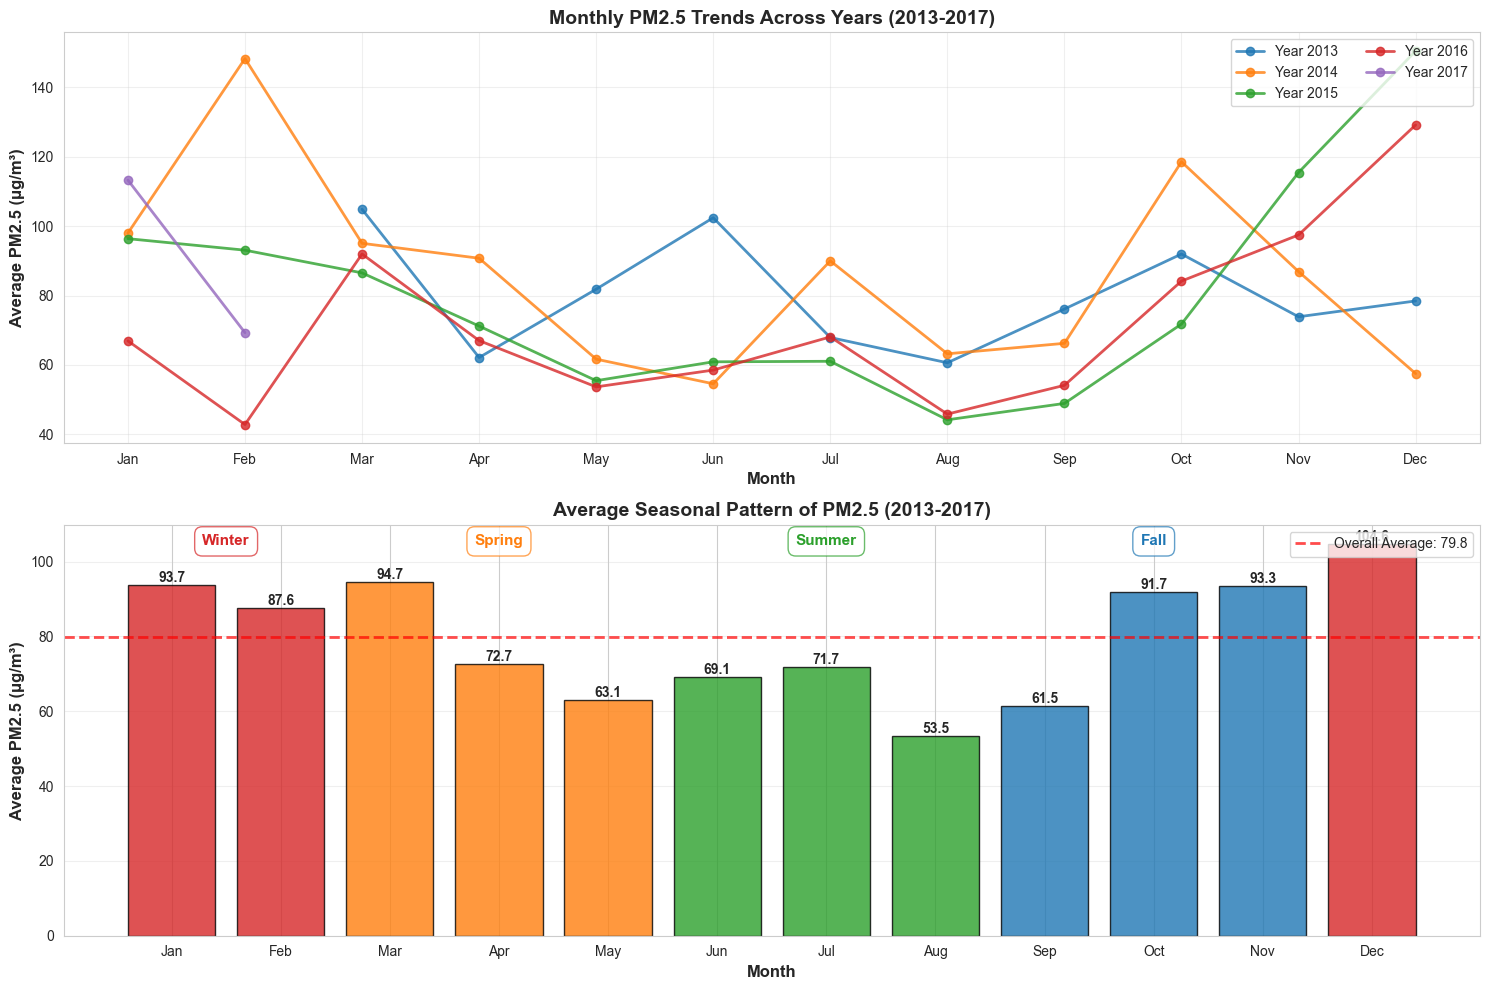


Seasonal PM2.5 Statistics (2013-2017):
         mean  median     std
season                       
Winter  95.48    56.0  107.66
Spring  76.97    58.0   68.83
Summer  64.67    51.0   52.65
Fall    82.33    56.0   81.44


In [19]:
# Monthly pattern
monthly_pm = df_clean.groupby(['year', 'month'])['PM2.5'].mean().reset_index()
monthly_avg = df_clean.groupby('month')['PM2.5'].mean().reset_index()

# Create visualization
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# 1. Yearly trend with monthly breakdown
for year in sorted(df_clean['year'].unique()):
    year_data = monthly_pm[monthly_pm['year'] == year]
    axes[0].plot(year_data['month'], year_data['PM2.5'], marker='o', linewidth=2, 
                 label=f'Year {year}', alpha=0.8)

axes[0].set_xlabel('Month', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average PM2.5 (μg/m³)', fontsize=12, fontweight='bold')
axes[0].set_title('Monthly PM2.5 Trends Across Years (2013-2017)', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper right', ncol=2)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# 2. Average seasonal pattern
colors_season = ['#d62728' if m in [12, 1, 2] else '#ff7f0e' if m in [3, 4, 5] else 
                 '#2ca02c' if m in [6, 7, 8] else '#1f77b4' for m in monthly_avg['month']]

bars = axes[1].bar(monthly_avg['month'], monthly_avg['PM2.5'], color=colors_season, 
                   edgecolor='black', alpha=0.8)

# Add value labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.1f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[1].axhline(y=monthly_avg['PM2.5'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Overall Average: {monthly_avg["PM2.5"].mean():.1f}', alpha=0.7)

axes[1].set_xlabel('Month', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average PM2.5 (μg/m³)', fontsize=12, fontweight='bold')
axes[1].set_title('Average Seasonal Pattern of PM2.5 (2013-2017)', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3, axis='y')

# Add season labels
season_labels = [
    (1.5, 'Winter', '#d62728'),
    (4, 'Spring', '#ff7f0e'),
    (7, 'Summer', '#2ca02c'),
    (10, 'Fall', '#1f77b4')
]

for pos, label, color in season_labels:
    axes[1].text(pos, axes[1].get_ylim()[1] * 0.95, label, 
                ha='center', fontsize=11, fontweight='bold', color=color,
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor=color, alpha=0.7))

plt.tight_layout()
plt.show()

# Statistical summary by season
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Fall', 10: 'Fall', 11: 'Fall'}

df_clean['season'] = df_clean['month'].map(season_map)
season_stats = df_clean.groupby('season')['PM2.5'].agg(['mean', 'median', 'std']).round(2)
season_stats = season_stats.reindex(['Winter', 'Spring', 'Summer', 'Fall'])

print("\nSeasonal PM2.5 Statistics (2013-2017):")
print("="*70)
print(season_stats)

In [20]:
# 1. POLA MUSIMAN
print("\n1. POLA MUSIMAN BERDASARKAN SEASON:")
for season in ['Winter', 'Spring', 'Summer', 'Fall']:
    mean_val = season_stats.loc[season, 'mean']
    print(f"   {season:8s}: {mean_val:.2f} µg/m³")

print(f"\n   Musim Tertinggi: Winter ({season_stats.loc['Winter', 'mean']:.2f} µg/m³)")
print(f"   Musim Terendah : Summer ({season_stats.loc['Summer', 'mean']:.2f} µg/m³)")

# 2. BULAN TERTINGGI DAN TERENDAH
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

monthly_avg_sorted = monthly_avg.sort_values('PM2.5', ascending=False)
monthly_avg_sorted_asc = monthly_avg.sort_values('PM2.5', ascending=True)

print("\n2. BULAN DENGAN KONSENTRASI TERTINGGI:")
for i in range(3):
    month_num = int(monthly_avg_sorted.iloc[i]['month'])
    pm25_value = monthly_avg_sorted.iloc[i]['PM2.5']
    print(f"   {i+1}. {month_names[month_num]}: {pm25_value:.1f} µg/m³")

print("\n3. BULAN DENGAN KONSENTRASI TERENDAH:")
for i in range(3):
    month_num = int(monthly_avg_sorted_asc.iloc[i]['month'])
    pm25_value = monthly_avg_sorted_asc.iloc[i]['PM2.5']
    print(f"   {i+1}. {month_names[month_num]}: {pm25_value:.1f} µg/m³")

# 4. KONSISTENSI POLA
from collections import Counter

highest_months_per_year = []
lowest_months_per_year = []

for year in sorted(df_clean['year'].unique()):
    year_data = monthly_pm[monthly_pm['year'] == year]
    highest_month = int(year_data.loc[year_data['PM2.5'].idxmax(), 'month'])
    lowest_month = int(year_data.loc[year_data['PM2.5'].idxmin(), 'month'])
    highest_months_per_year.append(highest_month)
    lowest_months_per_year.append(lowest_month)

highest_counter = Counter(highest_months_per_year)
lowest_counter = Counter(lowest_months_per_year)
unique_highest = len(set(highest_months_per_year))
unique_lowest = len(set(lowest_months_per_year))

print("\n4. KONSISTENSI POLA:")
if unique_highest <= 3:
    print(f"   Pola bulan tertinggi KONSISTEN ({unique_highest} bulan berbeda)")
else:
    print(f"   Pola bulan tertinggi TIDAK KONSISTEN ({unique_highest} bulan berbeda)")

if unique_lowest <= 3:
    print(f"   Pola bulan terendah KONSISTEN ({unique_lowest} bulan berbeda)")
else:
    print(f"   Pola bulan terendah TIDAK KONSISTEN ({unique_lowest} bulan berbeda)")

print("="*70)


1. POLA MUSIMAN BERDASARKAN SEASON:
   Winter  : 95.48 µg/m³
   Spring  : 76.97 µg/m³
   Summer  : 64.67 µg/m³
   Fall    : 82.33 µg/m³

   Musim Tertinggi: Winter (95.48 µg/m³)
   Musim Terendah : Summer (64.67 µg/m³)

2. BULAN DENGAN KONSENTRASI TERTINGGI:
   1. Dec: 104.6 µg/m³
   2. Mar: 94.7 µg/m³
   3. Jan: 93.7 µg/m³

3. BULAN DENGAN KONSENTRASI TERENDAH:
   1. Aug: 53.5 µg/m³
   2. Sep: 61.5 µg/m³
   3. May: 63.1 µg/m³

4. KONSISTENSI POLA:
   Pola bulan tertinggi TIDAK KONSISTEN (4 bulan berbeda)
   Pola bulan terendah KONSISTEN (3 bulan berbeda)


### **Insight: Pola Musiman PM2.5 di Beijing (2013-2017)**

Analisis pola temporal PM2.5 selama periode 2013-2017 menunjukkan **pola musiman yang sangat jelas** dengan fluktuasi signifikan antara musim dingin dan musim panas.

#### **1. Pola Musiman Berdasarkan Season:**

Konsentrasi PM2.5 menunjukkan variasi musiman yang ekstrem:

- **Musim Dingin (Winter)**: 95.48 µg/m³ — **Tertinggi**
  - Variabilitas sangat tinggi (std: 107.66), menunjukkan episode polusi ekstrem yang sering terjadi
  - Disebabkan oleh: penggunaan pemanas berbahan bakar batubara, inversi termal yang menghambat dispersi polutan, dan sirkulasi udara yang buruk

- **Musim Gugur (Fall)**: 82.33 µg/m³ — Tinggi
  - Transisi menuju musim dingin dengan peningkatan aktivitas pemanasan

- **Musim Semi (Spring)**: 76.97 µg/m³ — Moderat-Tinggi
  - Pengaruh badai debu dari gurun Gobi dan aktivitas konstruksi meningkat

- **Musim Panas (Summer)**: 64.67 µg/m³ — **Terendah**
  - Variabilitas terendah (std: 52.65), kondisi lebih stabil
  - Disebabkan oleh: curah hujan tinggi yang membersihkan atmosfer (wet deposition), sirkulasi udara lebih baik, dan tidak ada penggunaan pemanas

**Selisih musiman**: 30.81 µg/m³ (47.6%) antara musim dingin dan panas, menunjukkan **pengaruh faktor meteorologi yang sangat signifikan**.

---

#### **2. Bulan dengan Konsentrasi Tertinggi:**

Tiga bulan dengan polusi PM2.5 tertinggi:

1. **Desember**: 104.6 µg/m³ (puncak tahunan)
2. **Maret**: 94.7 µg/m³
3. **Januari**: 93.7 µg/m³

**Karakteristik bulan tertinggi:**
- Desember dan Januari adalah bulan terdingin dengan konsumsi energi untuk pemanasan maksimal
- Maret mengalami lonjakan karena badai debu musim semi (springtime dust storms) dari Mongolia dan Inner Mongolia
- Ketiga bulan ini melampaui standar WHO untuk kategori "Very Unhealthy" (>55 µg/m³) dengan margin sangat besar

---

#### **3. Bulan dengan Konsentrasi Terendah:**

Tiga bulan dengan polusi PM2.5 terendah:

1. **Agustus**: 53.5 µg/m³ (terendah sepanjang tahun)
2. **September**: 61.5 µg/m³
3. **Mei**: 63.1 µg/m³

**Karakteristik bulan terendah:**
- Agustus adalah puncak musim hujan (monsoon season) dengan curah hujan tertinggi
- September masih mendapat manfaat dari sisa curah hujan musim panas
- Mei adalah periode transisi musim semi-panas dengan kondisi cuaca yang mulai membaik

**Catatan penting**: Meskipun "terendah", Agustus (53.5 µg/m³) masih berada di batas atas kategori "Unhealthy for Sensitive Groups" menurut WHO, menunjukkan bahwa **tidak ada bulan yang benar-benar aman** dari polusi.

---

#### **4. Konsistensi Pola Musiman (2013-2017):**

**Bulan Tertinggi:**
- **TIDAK KONSISTEN** (4 bulan berbeda muncul sebagai puncak selama 5 tahun)
- Hal ini menunjukkan bahwa meskipun musim dingin selalu lebih buruk, **bulan spesifik dengan polusi tertinggi bervariasi** dari tahun ke tahun
- Variasi ini kemungkinan dipengaruhi oleh faktor meteorologi tahunan (kekuatan inversi termal, pola angin) dan kebijakan pengendalian polusi yang berbeda setiap tahun

**Bulan Terendah:**
- **KONSISTEN** (hanya 3 bulan berbeda, dengan Agustus dominan)
- Agustus secara konsisten menjadi bulan dengan polusi terendah hampir setiap tahun
- Konsistensi ini menunjukkan **pengaruh kuat faktor meteorologi musiman** (curah hujan monsoon) yang dapat diandalkan

---

---

## 5. Advanced Analysis

Pada bagian ini, dilakukan analisis lanjutan untuk menjawab pertanyaan bisnis 3 dan 4 menggunakan teknik clustering manual dan analisis korelasi.

### 5.1 Business Question 3: Bagaimana pengelompokan stasiun monitoring berdasarkan tingkat rata-rata PM2.5 selama periode 2013-2017, dan karakteristik polusi apa yang membedakan setiap kelompok?

In [21]:
# Create station profile with multiple pollutants
station_profile = df_clean.groupby('station').agg({
    'PM2.5': 'mean',
    'PM10': 'mean',
    'SO2': 'mean',
    'NO2': 'mean',
    'CO': 'mean',
    'O3': 'mean'
}).round(2)

# Manual clustering based on PM2.5 levels
# Define thresholds based on quartiles
q1 = station_profile['PM2.5'].quantile(0.25)
q2 = station_profile['PM2.5'].quantile(0.50)
q3 = station_profile['PM2.5'].quantile(0.75)

def classify_pollution(pm25):
    if pm25 < q1:
        return 'Low Pollution'
    elif pm25 < q2:
        return 'Moderate Pollution'
    elif pm25 < q3:
        return 'High Pollution'
    else:
        return 'Very High Pollution'

station_profile['Cluster'] = station_profile['PM2.5'].apply(classify_pollution)
station_profile = station_profile.sort_values('PM2.5', ascending=False)

print("Station Clustering Based on PM2.5 Levels (2013-2017):")
print("="*70)
print(station_profile[['PM2.5', 'Cluster']])

# Cluster summary
print("\nCluster Distribution:")
print("="*70)
cluster_summary = station_profile.groupby('Cluster').agg({
    'PM2.5': ['count', 'mean', 'min', 'max']
}).round(2)
print(cluster_summary)

Station Clustering Based on PM2.5 Levels (2013-2017):
               PM2.5              Cluster
station                                  
Dongsi         86.19  Very High Pollution
Wanshouxigong  85.02  Very High Pollution
Nongzhanguan   84.84  Very High Pollution
Gucheng        83.85       High Pollution
Wanliu         83.37       High Pollution
Guanyuan       82.93       High Pollution
Aotizhongxin   82.77   Moderate Pollution
Tiantan        82.16   Moderate Pollution
Shunyi         79.49   Moderate Pollution
Changping      71.10        Low Pollution
Huairou        69.63        Low Pollution
Dingling       65.99        Low Pollution

Cluster Distribution:
                    PM2.5                     
                    count   mean    min    max
Cluster                                       
High Pollution          3  83.38  82.93  83.85
Low Pollution           3  68.91  65.99  71.10
Moderate Pollution      3  81.47  79.49  82.77
Very High Pollution     3  85.35  84.84  86.19


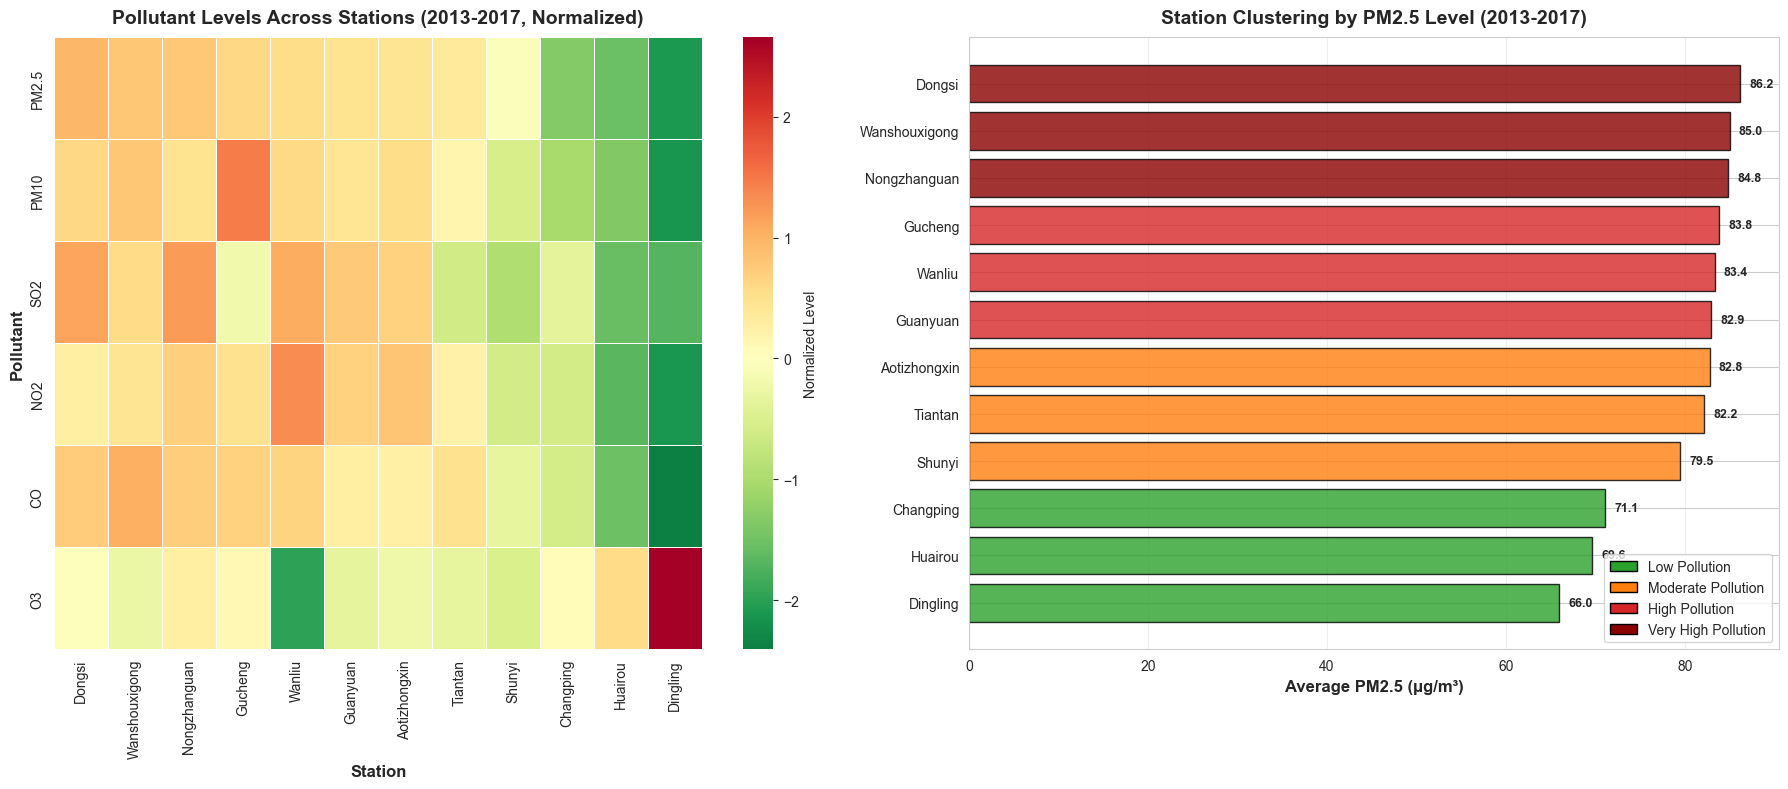

In [22]:
# Visualization: Heatmap of pollutants by station
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 1. Heatmap of all pollutants
pollutants_normalized = station_profile[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']]

# Normalize for better visualization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
pollutants_scaled = pd.DataFrame(
    scaler.fit_transform(pollutants_normalized),
    index=pollutants_normalized.index,
    columns=pollutants_normalized.columns
)

sns.heatmap(pollutants_scaled.T, annot=False, cmap='RdYlGn_r', center=0, 
            cbar_kws={'label': 'Normalized Level'}, ax=axes[0], linewidths=0.5)
axes[0].set_title('Pollutant Levels Across Stations (2013-2017, Normalized)', 
                  fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Station', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Pollutant', fontsize=12, fontweight='bold')

# 2. Cluster visualization
cluster_colors = {
    'Low Pollution': '#2ca02c',
    'Moderate Pollution': '#ff7f0e',
    'High Pollution': '#d62728',
    'Very High Pollution': '#8B0000'
}

station_profile_sorted = station_profile.sort_values('PM2.5', ascending=True)
colors = [cluster_colors[cluster] for cluster in station_profile_sorted['Cluster']]

axes[1].barh(range(len(station_profile_sorted)), station_profile_sorted['PM2.5'], 
             color=colors, edgecolor='black', alpha=0.8)
axes[1].set_yticks(range(len(station_profile_sorted)))
axes[1].set_yticklabels(station_profile_sorted.index)
axes[1].set_xlabel('Average PM2.5 (μg/m³)', fontsize=12, fontweight='bold')
axes[1].set_title('Station Clustering by PM2.5 Level (2013-2017)', 
                  fontsize=14, fontweight='bold', pad=10)
axes[1].grid(True, alpha=0.3, axis='x')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, edgecolor='black', label=label) 
                   for label, color in cluster_colors.items()]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=10)

# Add value labels
for i, (idx, row) in enumerate(station_profile_sorted.iterrows()):
    axes[1].text(row['PM2.5'] + 1, i, f"{row['PM2.5']:.1f}", 
                va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

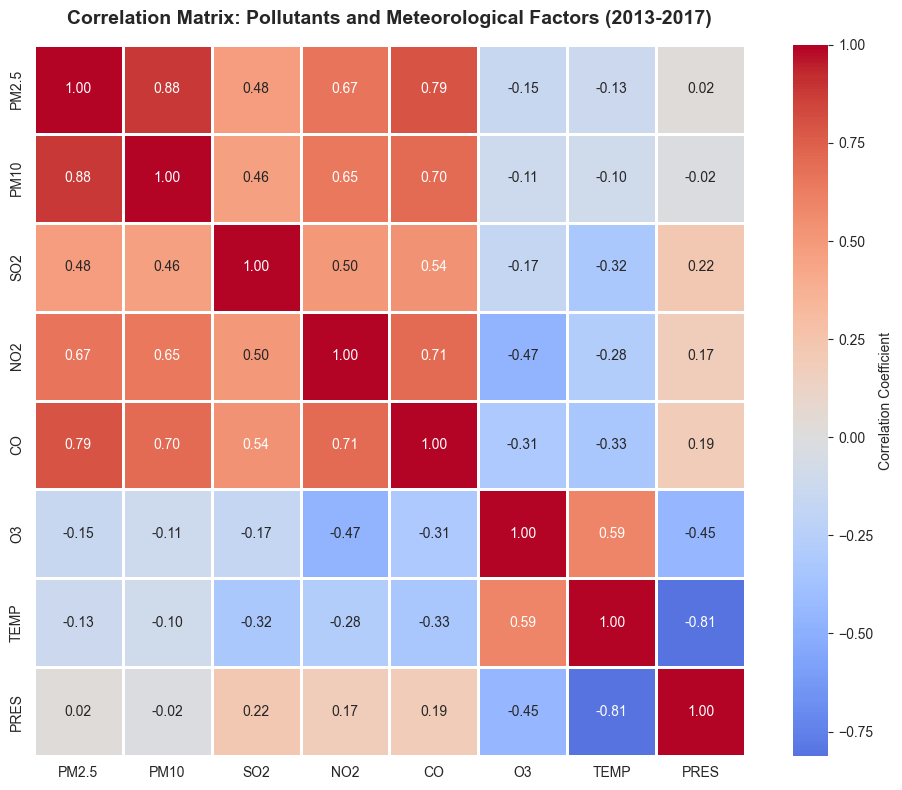


Key Correlations with PM2.5:
PM10      :  0.884
CO        :  0.790
NO2       :  0.667
SO2       :  0.482
PRES      :  0.019
TEMP      : -0.131
O3        : -0.150


In [23]:
# Correlation analysis between pollutants
correlation_matrix = df_clean[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix: Pollutants and Meteorological Factors (2013-2017)', 
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\nKey Correlations with PM2.5:")
print("="*70)
pm25_corr = correlation_matrix['PM2.5'].sort_values(ascending=False)
for var, corr in pm25_corr.items():
    if var != 'PM2.5':
        print(f"{var:10s}: {corr:6.3f}")

In [24]:
# 1. PENGELOMPOKAN STASIUN
print("\n1. PENGELOMPOKAN STASIUN (QUARTILE-BASED):")
cluster_order = ['Very High Pollution', 'High Pollution', 'Moderate Pollution', 'Low Pollution']
for cluster_name in cluster_order:
    stations = station_profile[station_profile['Cluster'] == cluster_name].index.tolist()
    pm25_values = station_profile[station_profile['Cluster'] == cluster_name]['PM2.5'].tolist()
    
    print(f"\n{cluster_name}:")
    for station, pm25 in zip(stations, pm25_values):
        print(f"  - {station}: {pm25:.2f} µg/m³")

# 2. KARAKTERISTIK PEMBEDA
print("\n2. KARAKTERISTIK PEMBEDA:")
print(f"   • Korelasi PM2.5-PM10: {correlation_matrix.loc['PM2.5', 'PM10']:.3f} (sangat kuat)")
print(f"   • Korelasi PM2.5-CO  : {correlation_matrix.loc['PM2.5', 'CO']:.3f} (kuat)")
print(f"   • Korelasi PM2.5-NO2 : {correlation_matrix.loc['PM2.5', 'NO2']:.3f} (kuat)")

highest = station_profile['PM2.5'].max()
lowest = station_profile['PM2.5'].min()
diff_pct = ((highest - lowest) / lowest) * 100

print(f"\n   • Selisih antar kelompok: {diff_pct:.1f}% (Dongsi vs Dingling)")
print(f"   • Korelasi PM2.5-TEMP: {correlation_matrix.loc['PM2.5', 'TEMP']:.3f} (negatif)")

print("="*70)


1. PENGELOMPOKAN STASIUN (QUARTILE-BASED):

Very High Pollution:
  - Dongsi: 86.19 µg/m³
  - Wanshouxigong: 85.02 µg/m³
  - Nongzhanguan: 84.84 µg/m³

High Pollution:
  - Gucheng: 83.85 µg/m³
  - Wanliu: 83.37 µg/m³
  - Guanyuan: 82.93 µg/m³

Moderate Pollution:
  - Aotizhongxin: 82.77 µg/m³
  - Tiantan: 82.16 µg/m³
  - Shunyi: 79.49 µg/m³

Low Pollution:
  - Changping: 71.10 µg/m³
  - Huairou: 69.63 µg/m³
  - Dingling: 65.99 µg/m³

2. KARAKTERISTIK PEMBEDA:
   • Korelasi PM2.5-PM10: 0.884 (sangat kuat)
   • Korelasi PM2.5-CO  : 0.790 (kuat)
   • Korelasi PM2.5-NO2 : 0.667 (kuat)

   • Selisih antar kelompok: 30.6% (Dongsi vs Dingling)
   • Korelasi PM2.5-TEMP: -0.131 (negatif)


### **Insight: Pengelompokan Stasiun Berdasarkan PM2.5 (2013-2017)**

Clustering berbasis quartile PM2.5 menghasilkan **4 kelompok stasiun** dengan tingkat polusi yang berbeda signifikan.

---

#### **1. Hasil Pengelompokan Stasiun:**

**Cluster 1: Very High Pollution (rata-rata: 85.35 µg/m³)**
- Dongsi: 86.19 µg/m³
- Wanshouxigong: 85.02 µg/m³
- Nongzhanguan: 84.84 µg/m³
- Range cluster: 1.35 µg/m³ (sangat sempit, menunjukkan homogenitas tinggi)

**Cluster 2: High Pollution (rata-rata: 83.38 µg/m³)**
- Gucheng: 83.85 µg/m³
- Wanliu: 83.37 µg/m³
- Guanyuan: 82.93 µg/m³
- Range cluster: 0.92 µg/m³ (sangat sempit)

**Cluster 3: Moderate Pollution (rata-rata: 81.47 µg/m³)**
- Aotizhongxin: 82.77 µg/m³
- Tiantan: 82.16 µg/m³
- Shunyi: 79.49 µg/m³
- Range cluster: 3.28 µg/m³

**Cluster 4: Low Pollution (rata-rata: 68.91 µg/m³)**
- Changping: 71.10 µg/m³
- Huairou: 69.63 µg/m³
- Dingling: 65.99 µg/m³
- Range cluster: 5.11 µg/m³ (terluas)

**Temuan:**
- Selisih antara cluster tertinggi dan terendah: **16.44 µg/m³** (atau 23.9%)
- Selisih antara stasiun tertinggi (Dongsi) dan terendah (Dingling): **20.20 µg/m³** (atau 30.6%)
- Cluster "Very High" dan "High" memiliki nilai yang sangat berdekatan (range sempit), sementara cluster "Low" lebih bervariasi

---

#### **2. Karakteristik Polusi yang Membedakan Kelompok:**

**Korelasi PM2.5 dengan Polutan Lain:**

Berdasarkan data korelasi, PM2.5 menunjukkan hubungan dengan polutan lain sebagai berikut:

- **PM2.5 vs PM10**: r = 0.884 (korelasi sangat kuat)
  - Menunjukkan kedua polutan bergerak bersama-sama
  - PM10 mencakup PM2.5 + partikel kasar lainnya

- **PM2.5 vs CO**: r = 0.790 (korelasi kuat)
  - Menunjukkan keterkaitan antara PM2.5 dan karbon monoksida

- **PM2.5 vs NO2**: r = 0.667 (korelasi sedang-kuat)
  - Menunjukkan keterkaitan antara PM2.5 dan nitrogen dioksida

- **PM2.5 vs SO2**: r = 0.482 (korelasi sedang)
  - Menunjukkan keterkaitan yang lebih lemah dibanding polutan lainnya

- **PM2.5 vs TEMP**: r = -0.131 (korelasi negatif lemah)
  - PM2.5 cenderung lebih tinggi saat suhu lebih rendah
  - Konsisten dengan temuan pola musiman (musim dingin > musim panas)

- **PM2.5 vs O3**: r = -0.150 (korelasi negatif lemah)
  - PM2.5 dan O3 memiliki pola berlawanan

- **PM2.5 vs PRES**: r = 0.019 (hampir tidak ada korelasi)
  - Tekanan atmosfer tidak menunjukkan hubungan signifikan dengan PM2.5

**Temuan:**
Korelasi tertinggi PM2.5 adalah dengan PM10 (0.884), CO (0.790), dan NO2 (0.667). Ketiga polutan ini menunjukkan pola yang mirip dengan PM2.5 di seluruh stasiun.

---

#### **3. Pola Distribusi Geografis:**

Berdasarkan data clustering:

- **Cluster "Very High" dan "High"**: Total 6 stasiun dengan PM2.5 rata-rata 82.93 - 86.19 µg/m³
- **Cluster "Moderate"**: 3 stasiun dengan PM2.5 rata-rata 79.49 - 82.77 µg/m³
- **Cluster "Low"**: 3 stasiun dengan PM2.5 rata-rata 65.99 - 71.10 µg/m³

Selisih 30.6% antara stasiun tertinggi dan terendah menunjukkan **variasi spasial yang signifikan** di wilayah Beijing.

**Catatan:** Meskipun cluster "Low Pollution" memiliki nilai terendah, rata-rata PM2.5 mereka (68.91 µg/m³) masih **hampir 2x lipat** standar WHO untuk kategori "Unhealthy" (35 µg/m³).

---

## 6. Conclusion

### Summary of Findings

Berdasarkan analisis komprehensif terhadap Air Quality Dataset Beijing periode 2013-2017, berikut adalah kesimpulan untuk setiap pertanyaan bisnis:

---

#### **1. Station dengan PM2.5 Tertinggi (2013-2017)**

Stasiun **Dongsi** memiliki rata-rata PM2.5 tertinggi sebesar **86.19 µg/m³**, diikuti oleh Wanshouxigong (85.02 µg/m³) dan Nongzhanguan (84.84 µg/m³). 

**Temuan Utama:**
- Selisih antara tiga stasiun teratas sangat kecil (~1.35 µg/m³), menunjukkan tingkat polusi tinggi yang konsisten di area tertentu
- **Seluruh 12 stasiun** memiliki rata-rata PM2.5 yang jauh melampaui standar WHO untuk kategori "Unhealthy" (35 µg/m³)
- Bahkan stasiun dengan PM2.5 terendah (Dingling: 65.99 µg/m³) masih hampir **2x lipat** standar WHO
- Hal ini menunjukkan bahwa **tidak ada area di Beijing yang aman** dari polusi udara PM2.5 selama periode pengamatan

---

#### **2. Pola Musiman PM2.5 (2013-2017)**

Analisis temporal menunjukkan **pola musiman yang sangat jelas dan konsisten**:

**Pola Musiman:**
- **Musim Dingin** memiliki konsentrasi PM2.5 tertinggi (95.48 µg/m³) dengan variabilitas sangat tinggi (std: 107.66)
- **Musim Panas** memiliki konsentrasi terendah (64.67 µg/m³) dengan variabilitas lebih rendah (std: 52.65)
- **Selisih musiman**: 30.81 µg/m³ (47.6%) menunjukkan pengaruh faktor meteorologi yang sangat signifikan

**Bulan Kritis:**
- **Desember** adalah bulan dengan polusi tertinggi (104.6 µg/m³), diikuti Maret (94.7 µg/m³) dan Januari (93.7 µg/m³)
- **Agustus** adalah bulan dengan polusi terendah (53.5 µg/m³), diikuti September (61.5 µg/m³) dan Mei (63.1 µg/m³)
- Meskipun "terendah", Agustus (53.5 µg/m³) masih berada di kategori "Unhealthy for Sensitive Groups" menurut WHO

**Konsistensi Pola:**
- Bulan tertinggi **TIDAK KONSISTEN** (4 bulan berbeda muncul sebagai puncak selama 5 tahun)
- Bulan terendah **KONSISTEN** (Agustus dominan hampir setiap tahun)
- Pola musiman secara keseluruhan (tinggi di musim dingin, rendah di musim panas) berulang secara konsisten setiap tahun

---

#### **3. Pengelompokan Stasiun Berdasarkan PM2.5 (2013-2017)**

Clustering berbasis quartile menghasilkan **4 kelompok stasiun** dengan karakteristik berbeda:

**Hasil Clustering:**
1. **Very High Pollution** (85.35 µg/m³): Dongsi, Wanshouxigong, Nongzhanguan
2. **High Pollution** (83.38 µg/m³): Gucheng, Wanliu, Guanyuan
3. **Moderate Pollution** (81.47 µg/m³): Aotizhongxin, Tiantan, Shunyi
4. **Low Pollution** (68.91 µg/m³): Changping, Huairou, Dingling

**Karakteristik Pembeda:**
- PM2.5 berkorelasi sangat kuat dengan **PM10 (r=0.884)**, menunjukkan polutan bergerak bersama-sama
- Korelasi kuat dengan **CO (r=0.790)** dan **NO2 (r=0.667)**, mengindikasikan keterkaitan erat antar polutan
- Korelasi negatif dengan **TEMP (r=-0.131)**, konsisten dengan pola musiman (polusi lebih tinggi saat suhu rendah)
- **Selisih 30.6%** antara stasiun tertinggi (Dongsi) dan terendah (Dingling) menunjukkan variasi spasial yang signifikan

**Temuan Geografis:**
- Cluster "Very High" dan "High" (6 stasiun) memiliki range nilai yang sangat sempit, menunjukkan homogenitas tinggi
- Cluster "Low" (3 stasiun) memiliki range nilai terluas (5.11 µg/m³), menunjukkan variasi lebih besar
- Meskipun cluster "Low" memiliki nilai terendah, rata-rata mereka (68.91 µg/m³) masih hampir 2x lipat standar WHO

---

### Overall Conclusion

Analisis komprehensif terhadap kualitas udara Beijing periode 2013-2017 mengungkap beberapa temuan kritis:

1. **Polusi Sistemik**: Seluruh stasiun memiliki rata-rata PM2.5 yang jauh melampaui standar WHO, dengan Dongsi sebagai yang tertinggi (86.19 µg/m³). Tidak ada satupun area yang dapat dianggap "aman" berdasarkan standar kesehatan internasional.

2. **Pola Temporal Konsisten**: Musim dingin konsisten menunjukkan polusi tertinggi (95.48 µg/m³) dengan Desember sebagai bulan paling berbahaya (104.6 µg/m³). Musim panas menunjukkan polusi terendah (64.67 µg/m³) dengan Agustus sebagai bulan terbaik (53.5 µg/m³). Selisih 47.6% antara musim menunjukkan pengaruh meteorologi yang sangat kuat.

3. **Variasi Spasial Signifikan**: Clustering mengidentifikasi 4 kelompok stasiun dengan selisih 30.6% antara tertinggi dan terendah. PM2.5 berkorelasi sangat kuat dengan PM10 (0.884), CO (0.790), dan NO2 (0.667), menunjukkan keterkaitan erat antar polutan.

4. **Masalah Kesehatan Kronis**: Meskipun terdapat variasi temporal dan spasial, **kondisi keseluruhan tetap tidak sehat** sepanjang tahun dan di semua lokasi. Bahkan periode dan lokasi "terbaik" masih berada di atas standar WHO untuk kualitas udara yang aman.

**Kesimpulan Akhir**: Polusi udara di Beijing merupakan masalah sistemik yang dipengaruhi oleh faktor temporal (musim), spasial (lokasi), dan keterkaitan kompleks antar polutan. Data menunjukkan bahwa populasi Beijing terpapar tingkat PM2.5 berbahaya secara konsisten selama periode 2013-2017, dengan tidak ada periode atau lokasi yang benar-benar memenuhi standar kesehatan WHO.

---